In [2]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io as sio
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}
plt.rc('font', **font)

In [3]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

In [4]:
def plot_TFIM(server,J,h,n_qubits,D,T,save=False):
    path='runs_'+server+'/'
    eig=sio.loadmat(path+'eigsTFIM/N%d_J%1.1f_h%1.1f.mat'%(n_qubits,J,h))
    E0=eig['E0']
    psigs=eig['psi0']
    ACQ=sio.loadmat(path+'runs_ACQ/ACQ_TFIM_J%1.1f_h%1.1f_N%d_D%d_T%d.mat'%(J,h,n_qubits,D,T))
    EACQ=ACQ['E'][0]
    FACQ=ACQ['F'][0]
    indx=ACQ['indx'][0]
    NACQ=indx[-1]+1
    tACQ=np.arange(0,len(indx))
    QITE=sio.loadmat(path+'runs_QITE/QITE_TFIM_J%1.1f_h%1.1f_N%d_D%d_T%d.mat'%(J,h,n_qubits,D,T))
    EQ=QITE['E'][0]
    NQ=len(EQ)
    tQ=np.arange(0,NQ)
    FQ=QITE['F'][0]
    
    plt.figure(figsize=(16, 6))
    plt.suptitle("TFIM $J=%.2f$, $h=%.2f$, $N=%d$"%(J,h,n_qubits))
    plt.subplot(1,2,1)
    plt.hlines(E0,0,NACQ,'k',linewidth=3,label='$E_{gs}$')
    plt.plot(tQ,EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
    plt.plot(np.arange(0,NACQ),EACQ[0:NACQ],'-ro',linewidth=3,label='ACQ $D=%d$'%D,alpha=0.5)
    plt.plot(indx,EACQ[indx],'kx',linewidth=3)
    plt.plot(tACQ,EACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
    plt.xlabel("Number of steps")
    plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
    plt.xlim(0, NACQ)
    plt.legend()
    plt.grid(linestyle = '--', linewidth = 1.5)


    plt.subplot(1,2,2)
    plt.plot(tQ,FQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
    plt.plot(tACQ,FACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
    #plt.plot(indx,F1[indx],'-ko',linewidth=3,label='ACQ Exited $D=%d$'%D)
    plt.xlabel("Number of steps")
    plt.ylabel("Fidelity")
    plt.xlim(0,NACQ)
    plt.ylim(0,1)
    plt.legend()
    plt.grid(linestyle = '--', linewidth = 1.5)

    if save:
        plt.savefig('TFIM_J%1.1f_h%1.1f_N%d_D%d_T%d.eps'%(J,h,n_qubits,D,T))


In [5]:
def fidelity_scale(J,h,n_qubits,D,T,server):
    path='runs_'+server+'/'
    F_ACQ=np.zeros((len(n_qubits),len(D)))
    F_Q=np.zeros((len(n_qubits),len(D)))
    iN=0
    for n in n_qubits:
        iD=0
        for d in D:
            ACQ=sio.loadmat(path+'runs_ACQ/ACQ_TFIM_J%1.1f_h%1.1f_N%d_D%d_T%d.mat'%(J,h,n,d,T))
            FACQ=ACQ['F'][0]
            indx=ACQ['indx'][0]
            QITE=sio.loadmat(path+'runs_QITE/QITE_TFIM_J%1.1f_h%1.1f_N%d_D%d_T%d.mat'%(J,h,n,d,T))
            FQ=QITE['F'][0]
            F_Q[iN,iD]=FQ[-1]
            F_ACQ[iN,iD]=FACQ[indx[-1]]
            iD=iD+1
        iN=iN+1
    return F_Q,F_ACQ


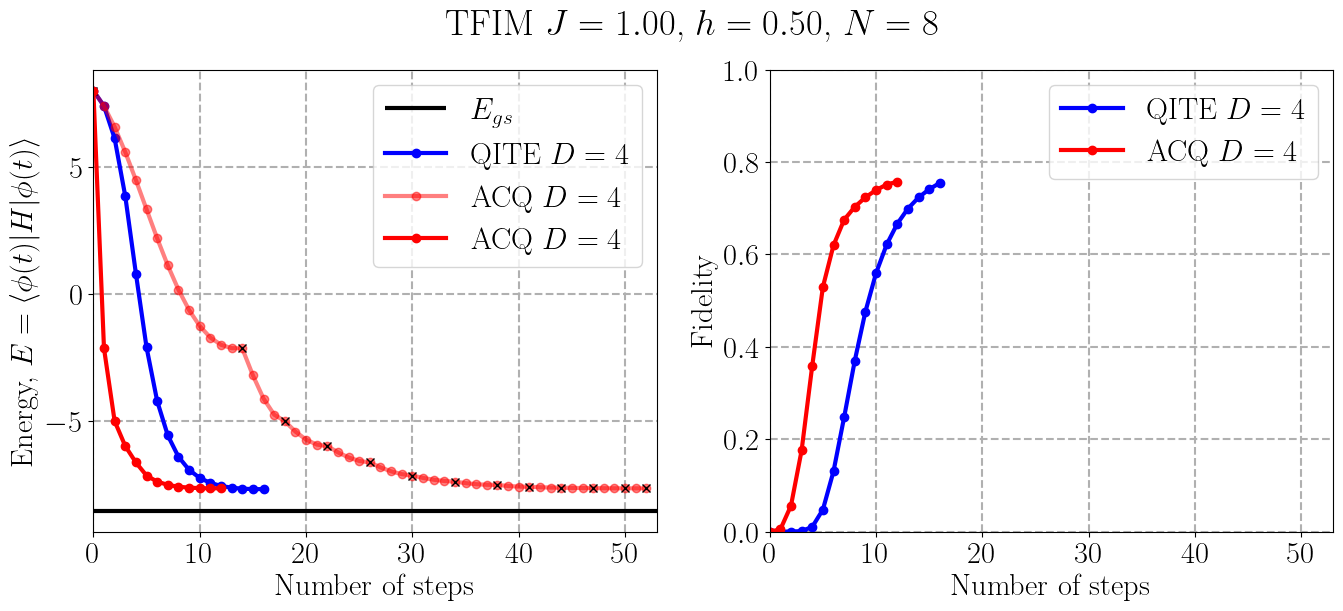

In [10]:
#Hamiltonian Params Traverse Field Ising model
n_qubits=range(6,10)
D=range(2,7,2)
J=1
h=0.5
T=2
server='vives'
plot_TFIM(server,J,h,8,4,T)
#FQ,FACQ=fidelity_scale(J,h,n_qubits,D,T,server)

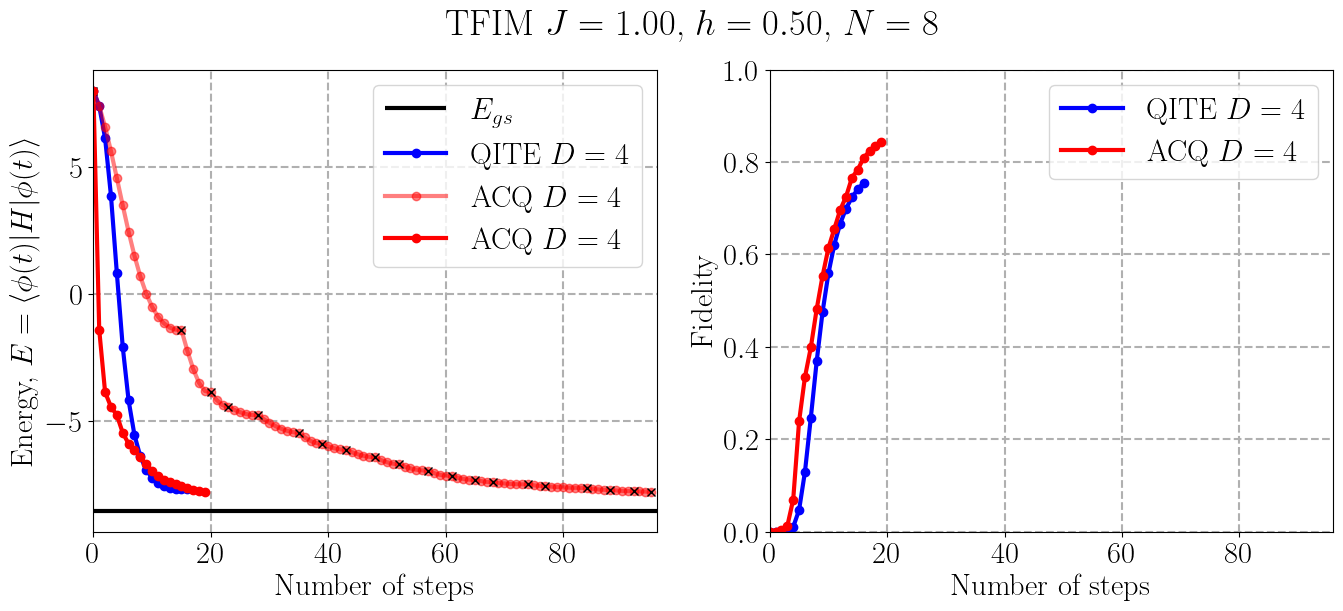

In [11]:
plot_TFIM('local',J,h,8,4,T)

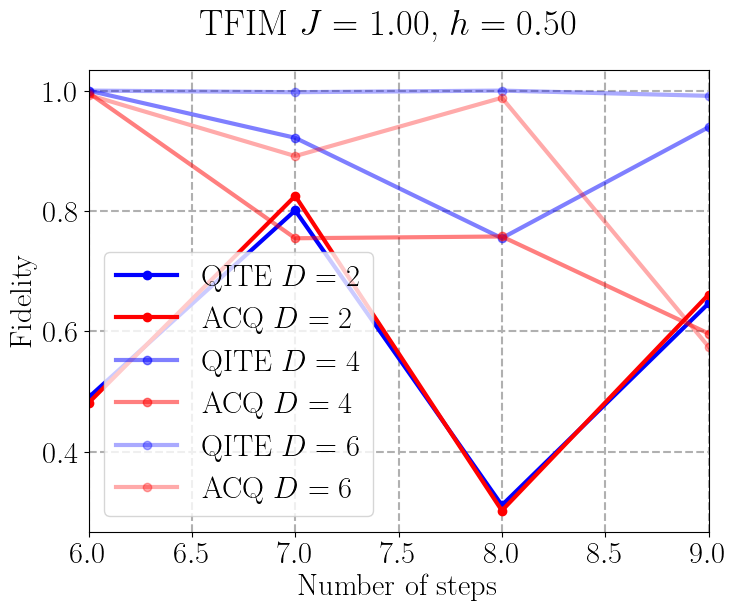

In [106]:
plt.figure(figsize=(8, 6))
plt.suptitle("TFIM $J=%.2f$, $h=%.2f$"%(J,h))
iD=0
for d in D:
    plt.plot(n_qubits,FQ[:,iD],'-bo',linewidth=3,label='QITE $D=%d$'%d,alpha=1/(iD+1))
    plt.plot(n_qubits,FACQ[:,iD],'-ro',linewidth=3,label='ACQ $D=%d$'%d,alpha=1/(iD+1))
    iD+=1
plt.xlabel("Number of steps")
plt.ylabel("Fidelity")

plt.xlim(n_qubits[0],n_qubits[-1])
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)